# Imports

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from scipy.signal import correlate
from scipy.interpolate import interp1d
from hapi import *
from pylab import plot
import pickle
from scipy.stats import chi2
from scipy.stats import norm
import matplotlib.ticker as ticker
from pathlib import Path
import gc
from concurrent.futures import ProcessPoolExecutor, as_completed


# from bin_spec import bin_spectrum
import seaborn as sns

%matplotlib inline

In [14]:
# data_path = '/Users/zaniaccollins/Research/SGL/sgl_science_case/data/spectra_xsc_atm'

data_path = '/home/zaniacco/orcd/pool/sgl_science_case/spectra_dict_cache_dwn1e-4_behemoth_test'
data_path_test = '/home/zaniacco/orcd/pool/sgl_science_case/spectra_dict_cache_dwn1e-4_behemoth_test'#spectra_dict_cache_dwn1e-4_behemoth_test_isoprene_nosulfur'
# spectra_dict_path = f'{data_path}spectra_dict_cache_dwn1e-4_earth/'

# Helper functions

In [16]:
def get_molecule_id(molecule_name):
    """Return (M, common_local_I) for a molecule by name"""
    for (M, I), data in hapi.ISO.items():
        if data[4].upper() == molecule_name.upper():   # data[4] is the molecule name like 'N2O'
            return M, I   # returns first (main) isotopologue
    raise ValueError(f"Molecule {molecule_name} not found in hapi.ISO")

def cross_correlate_spectra(template_spectra, test_spectra, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation between two spectra.
    Returns a dictionary with all relevant results.
    """
    # Zero-mean normalization
    template_norm = (template_spectra - np.mean(template_spectra)) / np.std(template_spectra)
    test_norm     = (test_spectra     - np.mean(test_spectra))     / np.std(test_spectra)
    
    # Cross-correlation
    ccf = correlate(template_norm, test_norm, mode='full')
    ccf /= np.sqrt(np.sum(template_norm**2) * np.sum(test_norm**2))
    
    # Lags
    if lags is None:
        lags = np.arange(-len(template_norm) + 1, len(template_norm))
    
    # Basic statistics
    max_corr = np.max(ccf)
    peak_idx = np.argmax(ccf)
    
    # Noise estimation from wings (excluding central peak)
    window_size = int(0.15 * len(ccf))
    noise_mask = np.ones(len(ccf), dtype=bool)
    noise_mask[max(0, peak_idx - window_size): min(len(ccf), peak_idx + window_size)] = False
    noise_values = ccf[noise_mask]
    noise_std = np.std(noise_values) if len(noise_values) > 20 else np.std(ccf)
    
    # SNR array
    cc_snr = ccf / noise_std if noise_std > 0 else np.zeros_like(ccf)
    
    results = {
        'ccf': ccf,
        'lags': lags,
        'max_correlation': max_corr,
        'peak_lag': lags[peak_idx],
        'noise_std': noise_std,
        'template_norm': template_norm,
        'test_norm': test_norm,
    }
    
    if return_full:
        results['ccf_clean'] = np.clip(np.nan_to_num(ccf, nan=0.0), 0, None)
    
    return results

def compute_log_likelihood(template, test):
    """
    Continuum-subtracted Gaussian log-likelihood (up to an additive constant).
    Model: test ≈ a * template + noise
    logL = -N/2 * log(mean residual^2)
    """
    f = np.asarray(template, dtype=float)
    g = np.asarray(test, dtype=float)
    
    m = np.isfinite(f) & np.isfinite(g)
    f, g = f[m], g[m]

    f = f - np.mean(f)
    g = g - np.mean(g)

    N = f.size
    denom = np.dot(f, f)

    if denom <= 0 or N < 2:
        return -np.inf, 0.0

    # a = np.dot(f, g) / denom
    a = 1
    
    #Compute variances
    sf2 = np.dot(f,f)/N
    sg2 = np.dot(g,g)/N
    R = np.dot(f,g)/N

    arg = sf2 - 2.0 * a * R + a**2 * sg2
    
    # residual = g - a * f
    # sigma2 = np.dot(residual, residual) / N

    logL = -0.5 * N * np.log(arg)
    return logL, a

def load_scenario(scenario_key, out_dir=None):

    path = os.path.join(out_dir, f"{scenario_key}.pkl")
    with open(path, "rb") as f:
        return pickle.load(f)
    
def check_spec(name, x):
    x = np.asarray(x, float)
    print(name,
          "len", len(x),
          "nan", np.isnan(x).sum(),
          "inf", np.isinf(x).sum(),
          "std", np.nanstd(x),
          "min/max", np.nanmin(x), np.nanmax(x))


def cross_correlate_two_templates(template_A, template_B, test_scenario, in_dir = data_path, wl_min = None, wl_max = None, verbose = True):
    """
    Cross-correlate two specific clean templates against the noisy versions
    of a single test scenario.
    """  

    if verbose:
        print(f"Loading scenarios...")
    data_A = load_scenario(template_A, in_dir)
    data_B = load_scenario(template_B, in_dir)
    data_test = load_scenario(test_scenario, in_dir)
    

    # Only use resolutions that exist in all three
    common_resolutions = sorted(
        set(data_A.keys()) & set(data_B.keys()) & set(data_test.keys())
    )
    if verbose:
        print('Common resolutions: ', common_resolutions)
    if verbose:
        if wl_min is not None or wl_max is not None:
            print(f"Wavelength window: [{wl_min}, {wl_max}] µm")

    records = []

    for r in common_resolutions:
        # Check that everything we need exists
        wl = np.asarray(data_A[r]["wavelength_grid"], dtype=np.float64)

        # mask: finite, optional window, drop binning edge artifacts
        m = np.isfinite(wl)
        if wl_min is not None:
            m &= wl >= float(wl_min)
        if wl_max is not None:
            m &= wl <= float(wl_max)

        # also require same length grids on B and test
        wl_b = np.asarray(data_B[r]["wavelength_grid"], dtype=np.float64)
        wl_t = np.asarray(data_test[r]["wavelength_grid"], dtype=np.float64)
        if len(wl_b) != len(wl) or len(wl_t) != len(wl):
            print(f"  skip R={r}: wavelength grid length mismatch")
            continue

        # n_pix = int(np.count_nonzero(m))
        # if n_pix < 10:
        #     print(f"  skip R={r}: only {n_pix} pixels in window")
        #     continue

        template_A_spec = np.asarray(data_A[r]["flux_clean"], dtype=np.float64)[m]
        template_B_spec = np.asarray(data_B[r]["flux_clean"], dtype=np.float64)[m]
        
        if verbose:
            check_spec("A", template_A_spec)
            check_spec("B", template_B_spec)

        # Loop over noisy versions of the test scenario at this resolution
        for key in data_test[r]:
            if not key.startswith('flux_snr'):
                continue

            noisy_spec = np.asarray(data_test[r][key], dtype=np.float64)[m]
            if verbose:
                check_spec("data", noisy_spec)
            
            snr_value = int(key.split('snr')[-1])
            if verbose:
                print(f'Cross correlating at R = {r}, snr = {snr_value}')

            if len(template_A_spec) != len(noisy_spec):
                continue

            # Log-likelihoods
            log_lik_A, _ = compute_log_likelihood(template_A_spec, noisy_spec)
            log_lik_B, _ = compute_log_likelihood(template_B_spec, noisy_spec)

            delta_ll = log_lik_B - log_lik_A
            # delta_ll /= len(template_A_spec) #Convert to log_likelihood per bin

            ts = 2.0 * delta_ll
            p = chi2.sf(ts, df=1)
            if verbose:
                print(p)

            if delta_ll > 0: 
                sigma = (2.0 * delta_ll) ** 0.5 #Chi-squared for 1 d.o.f. maps to sqrt(deltall)
            elif delta_ll < 0:
                sigma = 0.0          # B not preferred → no detection of B over A
                # optional: sigma_A = (2.0 * (-delta_ll)) ** 0.5  # how strongly A wins
            else:
                sigma = 0.0
            if verbose:
                print(
                    f"R={r} SNR={snr_value}  "
                    f"logL_A={log_lik_A:.6e}  logL_B={log_lik_B:.6e}  "
                    f"delta={delta_ll:.6e}  sigma={sigma}"
                )

            # if r == 1e7:
            #     print('----------------------------------')
            #     print(f"  log_lik_A = {log_lik_A:.3f}")
            #     print(f"  log_lik_B = {log_lik_B:.3f}")
            #     print(f"  delta    = {log_lik_B - log_lik_A:.3f}")

            # delta_ll = log_lik_B - log_lik_A
            # ts = 2 * delta_ll
            # p = chi2.sf(ts, df=1)
            # sigma = norm.isf(p / 2.0)

            # print(f'sigma = {sigma}')

            records.append({
                'resolution': r,
                'snr': snr_value,
                'delta_logL': delta_ll,
                'sigma': sigma,
            })

            del noisy_spec
            gc.collect()

        del template_A_spec, template_B_spec
        gc.collect()

    # Free memory
    del data_A, data_B, data_test
    gc.collect()

    df = pd.DataFrame(records)
    # print(f"Generated {len(df)} records for {template_A} vs {template_B}")
    return df


def cross_correlate_blackbody_test(
    template_A,
    template_B,
    test_scenario,
    in_dir=data_path_test,
    wl_min=None,
    wl_max=None,
    verbose=True,
):

    data_A = load_scenario(template_A, in_dir)
    data_B = load_scenario(template_B, in_dir)
    data_test = load_scenario(test_scenario, in_dir)

    common_resolutions = sorted(
        set(data_A.keys()) & set(data_B.keys()) & set(data_test.keys())
    )
    if verbose:
        print("Common resolutions:", common_resolutions)

    records = []
    for r in common_resolutions:
        if r < 1.05e5:
            wl = np.asarray(data_A[r]["wavelength_grid"], dtype=np.float64)
            m = np.isfinite(wl)
            if wl_min is not None:
                m &= wl >= float(wl_min)
            if wl_max is not None:
                m &= wl <= float(wl_max)

            # if int(np.count_nonzero(m)) < 10:
            #     if verbose:
            #         print(f" skip R={r}: too few pixels")
            #     continue

            for key in data_test[r]:
                if not key.startswith("flux_snr"):
                    continue

                # ONE shared observation
                data_spec = np.asarray(data_test[r][key], dtype=np.float64)[m]
                template_A_spec = np.asarray(data_A[r][key], dtype=np.float64)[m]
                template_B_spec = np.asarray(data_B[r][key], dtype=np.float64)[m]
                snr_value = int(key.split("snr")[-1])

                if not (len(template_A_spec) == len(template_B_spec) == len(data_spec)):
                    continue

                log_lik_A, _ = compute_log_likelihood(template_A_spec, data_spec)
                log_lik_B, _ = compute_log_likelihood(template_B_spec, data_spec)
                delta_ll = log_lik_B - log_lik_A
                delta_ll_per_bin = delta_ll / len(data_spec)

                # signed diagnostic only — NOT a calibrated false-alarm rate
                signed_sigma = np.sign(delta_ll) * np.sqrt(2.0 * abs(delta_ll))

                if verbose:
                    print(
                        f"R={r} SNR={snr_value}  "
                        f"logL_A={log_lik_A:.6e}  logL_B={log_lik_B:.6e}  "
                        f"delta={delta_ll:.6e}  delta/N={delta_ll_per_bin:.3e}"
                    )

                records.append({
                    "resolution": r,
                    "snr": snr_value,
                    "log_lik_A": log_lik_A,
                    "log_lik_B": log_lik_B,
                    "delta_logL": delta_ll,
                    "delta_logL_per_bin": delta_ll_per_bin,
                    "signed_sigma_uncalibrated": signed_sigma,
                    "n_pix": int(m.sum()),
                })

    return pd.DataFrame(records)



# Spectra

In [23]:
def load_pkl_test(name):
    with open(f"{data_path_test}/{name}.pkl", "rb") as f:
        return pickle.load(f)

def load_pkl(name):
    with open(f"{data_path}/{name}.pkl", "rb") as f:
        return pickle.load(f)

res_dict_test = {
    # 'Isoprene': load_pkl_test('Isoprene_spectrum_VMR_boosted')
    # 'CH4': load_pkl_test('CH4_spectrum'),
    # 'N2O': load_pkl_test('N2O_spectrum'),
    # 'Blackbody_1': load_pkl_test('BLACKBODY_1'),
    # 'Blackbody_2': load_pkl_test('BLACKBODY_2'),
    # 'Blackbody_3': load_pkl_test('BLACKBODY_3')

    # "with_Isoprene": load_pkl("ALL_WITH_Isoprene"),
    # "without_Isoprene": load_pkl("ALL_WITHOUT_Isoprene"),
    # "with_N2O": load_pkl("CO2+CH4+N2O+H2O"),
    # "without_N2O": load_pkl("CO2+CH4+H2O"),    

    # "isoprene": load_pkl("Isoprene"),  # or whatever the single-species file is called
}

res_dict = {
    # 'Isoprene': load_pkl('Isoprene'),
    # "ALL_WITH_Isoprene": load_pkl("ALL_WITH_Isoprene"),
    # "ALL_WITHOUT_Isoprene": load_pkl("ALL_WITHOUT_Isoprene"),
    # "ALL_WITH_N2O": load_pkl("ALL_WITH_N2O"),
    # "ALL_WITHOUT_N2O": load_pkl("ALL_WITHOUT_N2O"),    
    "ALL_WITH_CH4": load_pkl("ALL_WITH_CH4"),
    "ALL_WITHOUT_CH4": load_pkl("ALL_WITHOUT_CH4"),    
    "CH4'": load_pkl("CH4")

    # "isoprene": load_pkl("Isoprene"),  # or whatever the single-species file is called
}

# R = 100000
# yw = res_dict["with_Isoprene"][R]["flux_clean"][1:-1]
# yo = res_dict["without_Isoprene"][R]["flux_clean"][1:-1]
# yw = res_dict["with_N2O"][R]["flux_clean"][1:-1]
# yo = res_dict["without_N2O"][R]["flux_clean"][1:-1]

# print(np.max(np.abs(yw - yo)))
# print(yw.mean(), yo.mean())
        

In [8]:
print(res_dict['ALL_WITH_CH4'].keys())

dict_keys([100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000])


## Just one

In [22]:
plt.figure(figsize=(10, 6))

plt_min, plt_max = 10, 12
R = 215443
snr = 10
R_key = int(R)

names = ["CH4"]
colors = ["C0"]

for name, color in zip(names, colors):
    d = res_dict[name][R_key]
    x = np.asarray(d["wavelength_grid"], dtype=np.float64)
    y = np.asarray(d[f"flux_snr{snr}"], dtype=np.float64)
    err = np.asarray(d[f"error_snr{snr}"], dtype=np.float64)

    m = np.isfinite(x) & np.isfinite(y) & (y > 0) & (x >= plt_min) & (x <= plt_max)
    # x, y, err = x[m], y[m], err[m]

    # plt.errorbar(
    #     x, y, yerr=err,
    #     label=f"{name} noisy (R={int(R)}, SNR={snr})",
    #     marker="o", ls="none", markersize=4, capsize=3,
    #     alpha=0.7, color=color, zorder=1,
    # )

    y_c = np.asarray(d["flux_clean"], dtype=np.float64)
    m_c = np.isfinite(x)
    x_c = np.asarray(d["wavelength_grid"], dtype=np.float64)
    y_c = np.asarray(d["flux_clean"], dtype=np.float64)
    m_c = np.isfinite(x_c) & np.isfinite(y_c) & (y_c > 0) & (x_c >= plt_min) & (x_c <= plt_max)
    plt.plot(x_c[m_c], y_c[m_c], lw=2, color=color, alpha=0.9, zorder=2,
             label=f"{name} clean")

# plt.yscale("log")
plt.xlim(plt_min, plt_max)
# plt.ylim(0,80)
plt.xlabel("Wavelength (µm)", fontsize=14)
plt.ylabel(
    r"$F_{\tilde{\nu}}$ (erg s$^{-1}$ cm$^{-2}$",
    fontsize=14,
)
plt.title(f"Noisy blackbodies at R = {int(R)}, SNR = {snr}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: 'CH4'

<Figure size 1000x600 with 0 Axes>

## Spectra plot

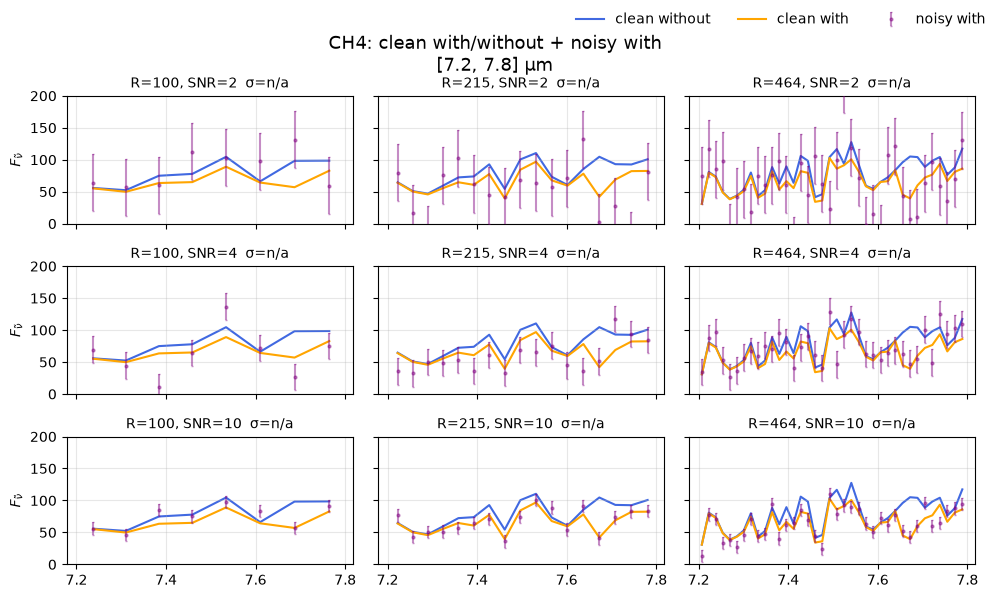

In [21]:
def plot_comparison_grid(
    res_dict,
    resolutions,
    snrs,
    wl_min,
    wl_max,
    flux_min=0.0,
    df_cc=None,
    mol_of_interest="Isoprene",
    scen_with=None,
    scen_without=None,
    show_errors=True,
    figsize=None,
):
    """
    Grid of spectra: rows = SNR, columns = resolution.
    Each panel: clean without / clean with / noisy with (+ optional errors).
    Title includes detection sigma from df_cc when available.
    """
    if scen_with is None:
        scen_with = f"ALL_WITH_{mol_of_interest}"
    if scen_without is None:
        scen_without = f"ALL_WITHOUT_{mol_of_interest}"

    resolutions = list(resolutions)
    snrs = list(snrs)
    nrows, ncols = len(snrs), len(resolutions)
    if figsize is None:
        figsize = (4.2 * ncols, 3.2 * nrows)

    fig, axes = plt.subplots(
        nrows, ncols, figsize=figsize, sharex=True, sharey=True, squeeze=False
    )

    def lookup_sigma(R, snr):
        if df_cc is None:
            return None
        mask = (
            np.isclose(df_cc["resolution"].astype(float), float(R))
            & np.isclose(df_cc["snr"].astype(float), float(snr))
        )
        sub = df_cc.loc[mask]
        if len(sub) == 0:
            return None
        return float(sub["sigma"].mean())

    for i, snr in enumerate(snrs):
        for j, R in enumerate(resolutions):
            ax = axes[i, j]
            R_key = int(R) if int(R) in res_dict[scen_with] else R

            d_with = res_dict[scen_with][R_key]
            d_without = res_dict[scen_without][R_key]

            x_w = np.asarray(d_with["wavelength_grid"], dtype=np.float64)
            y_with_clean = np.asarray(d_with["flux_clean"], dtype=np.float64)
            y_with_noisy = np.asarray(
                d_with[f"flux_snr{int(snr)}"], dtype=np.float64
            )
            err_with = np.asarray(d_with[f"error_snr{int(snr)}"], dtype=np.float64)

            x_o = np.asarray(d_without["wavelength_grid"], dtype=np.float64)
            y_without_clean = np.asarray(
                d_without["flux_clean"], dtype=np.float64
            )

            m_w = (
                np.isfinite(x_w)
                & np.isfinite(y_with_clean)
                & np.isfinite(y_with_noisy)
                & (y_with_clean > flux_min)
                & (x_w >= wl_min)
                & (x_w <= wl_max)
            )
            m_o = (
                np.isfinite(x_o)
                & np.isfinite(y_without_clean)
                & (y_without_clean > flux_min)
                & (x_o >= wl_min)
                & (x_o <= wl_max)
            )

            x_w = x_w[m_w]
            y_with_clean = y_with_clean[m_w]
            y_with_noisy = y_with_noisy[m_w]
            err_with = err_with[m_w]
            x_o = x_o[m_o]
            y_without_clean = y_without_clean[m_o]

            sig = lookup_sigma(R, snr)
            sig_str = f"  σ={sig:.2f}" if sig is not None else "  σ=n/a"

            if show_errors:
                ax.errorbar(
                    x_w,
                    y_with_noisy,
                    yerr=err_with,
                    marker="o",
                    ls="none",
                    markersize=2,
                    capsize=1,
                    alpha=0.45,
                    color="purple",
                    zorder=3,
                    label="noisy with",
                )
            else:
                ax.plot(
                    x_w,
                    y_with_noisy,
                    ls="none",
                    marker="o",
                    markersize=2,
                    alpha=0.45,
                    color="purple",
                    zorder=3,
                    label="noisy with",
                )

            ax.plot(
                x_o,
                y_without_clean,
                lw=1.5,
                color="royalblue",
                zorder=1,
                label="clean without",
            )
            ax.plot(
                x_w,
                y_with_clean,
                lw=1.5,
                color="orange",
                zorder=2,
                label="clean with",
            )

            ax.set_title(f"R={int(R)}, SNR={int(snr)}{sig_str}", fontsize=10)
            ax.grid(True, alpha=0.3)
            # if i == nrows - 1:
            #     ax.set_xlabel("Wavelength (µm)")
            if j == 0:
                ax.set_ylabel(r"$F_{\tilde{\nu}}$")
            ax.set_ylim(0,200)

    # one legend for the whole figure
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=3, frameon=False)
    fig.suptitle(
        f"{mol_of_interest}: clean with/without + noisy with\n"
        f"[{wl_min}, {wl_max}] µm",
        y=.95,
        fontsize=13,
    )
    fig.tight_layout()
    plt.show()
    return fig, axes


# example
plot_comparison_grid(
    res_dict,
    resolutions=[100,215,464],#, 1e4, 1e5],
    snrs=[2,4,10],
    wl_min=7.2,
    wl_max=7.8,
    flux_min=0.0,
    # df_cc=df_cc,
    mol_of_interest="CH4",
    show_errors=True,
    figsize = (10,6)
);

# Results

## Blackbody test

In [33]:
template_A="BLACKBODY_1"
template_B="BLACKBODY_2" 
test_scenario="BLACKBODY_3"

df_cc_test = cross_correlate_blackbody_test(
    template_A="BLACKBODY_1",
    template_B="BLACKBODY_2",   
    test_scenario="BLACKBODY_3", 
    wl_min=5.0,
    wl_max=10.0,
)
print(df_cc["delta_logL"].describe())
print(df_cc["delta_logL_per_bin"].describe())

Common resolutions: [100, 1000, 10000, 100000, 1000000, 10000000]
R=100 SNR=3  logL_A=2.491295e+01  logL_B=2.267853e+01  delta=-2.234417e+00  delta/N=-3.238e-02
R=100 SNR=5  logL_A=5.245527e+01  logL_B=5.392886e+01  delta=1.473589e+00  delta/N=2.136e-02
R=100 SNR=10  logL_A=1.069008e+02  logL_B=1.036813e+02  delta=-3.219495e+00  delta/N=-4.666e-02
R=100 SNR=25  logL_A=1.701115e+02  logL_B=1.747929e+02  delta=4.681439e+00  delta/N=6.785e-02
R=100 SNR=50  logL_A=2.253654e+02  logL_B=2.138299e+02  delta=-1.153552e+01  delta/N=-1.672e-01
R=100 SNR=100  logL_A=2.668223e+02  logL_B=2.569970e+02  delta=-9.825251e+00  delta/N=-1.424e-01
R=1000 SNR=3  logL_A=2.166794e+02  logL_B=2.146510e+02  delta=-2.028366e+00  delta/N=-2.927e-03
R=1000 SNR=5  logL_A=5.905544e+02  logL_B=5.764199e+02  delta=-1.413445e+01  delta/N=-2.040e-02
R=1000 SNR=10  logL_A=1.058492e+03  logL_B=1.049595e+03  delta=-8.897509e+00  delta/N=-1.284e-02
R=1000 SNR=25  logL_A=1.672978e+03  logL_B=1.703164e+03  delta=3.018602e+0

KeyError: 'delta_logL_per_bin'

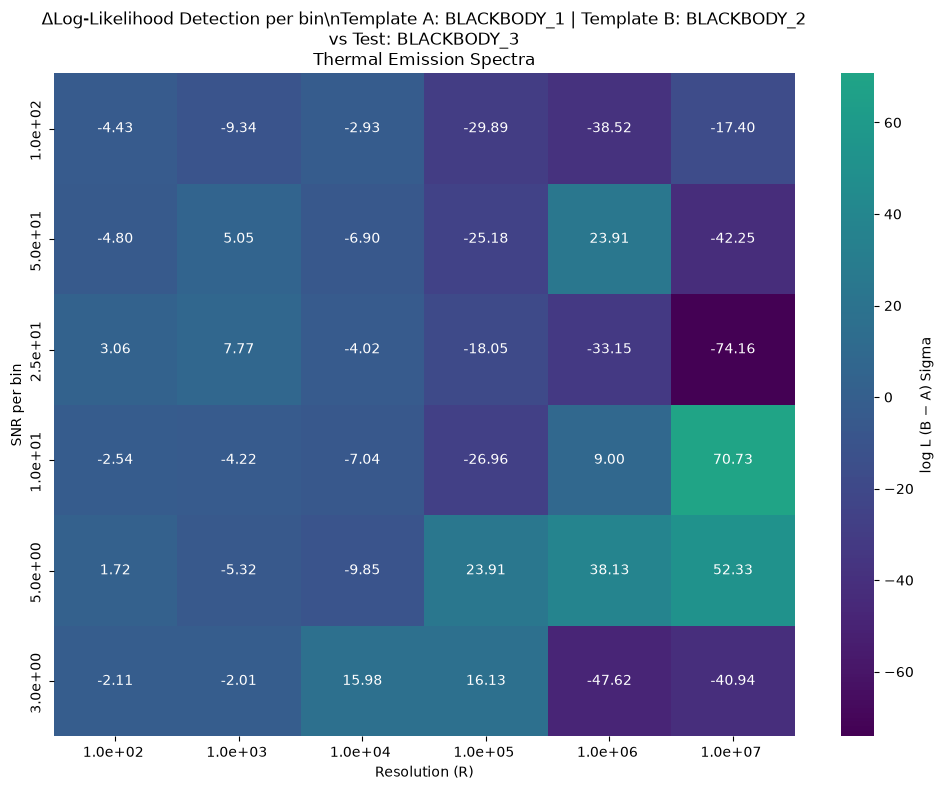

In [35]:
# merged = pd.merge(df_A, df_B, on=['resolution', 'snr'], suffixes=('_A', '_B'))

# Use log-likelihood difference (A - B)
# merged['delta_logL'] = merged['log_lik_B'] - merged['log_lik_A']

# Optional: compute significance (how many sigma the difference is)
# merged['delta_significance'] = merged['delta_logL'] / np.sqrt(merged['noise_std_A']**2 + merged['noise_std_B']**2)

# ======================
# Pivot for heatmap
# ======================
pivot = df_cc_test.pivot_table(
    index='snr', 
    columns='resolution', 
    values='signed_sigma_uncalibrated',        # or 'delta_significance'
    aggfunc='mean'
).sort_index(ascending=False)   # SNR increasing upwards

# ======================
# Annotation
# ======================
annot = pivot.copy().astype(str)

for i, snr in enumerate(pivot.index):
    for j, res in enumerate(pivot.columns):
        val = pivot.iloc[i, j]
        annot.iloc[i, j] = f"{val:.2f}"

# ======================
# Plot
# ======================
plt.figure(figsize=(10, 8))

ax=sns.heatmap(
    pivot,
    cmap='viridis',           
    center=50,
    annot=annot,
    fmt='', 
    cbar_kws={'label': 'log L (B − A) Sigma'}
)



xticklabels = [f"{r:.1e} "
               for r in pivot.columns]
yticklabels = [f"{snr:.1e} "
               for snr in pivot.index]
ax.set_xticklabels(xticklabels)
ax.set_yticklabels(yticklabels)

plt.xlabel('Resolution (R)')
plt.ylabel('SNR per bin')
plt.title(
    r'$\Delta$Log-Likelihood Detection per bin\n'
    f'Template A: {template_A} | Template B: {template_B}\n'
    f'vs Test: {test_scenario}\n'
    'Thermal Emission Spectra'
)

plt.tight_layout()
plt.show()

## Science Cases

In [ ]:
# plt.close('all')
wl_min_cc = 8
wl_max_cc = 12
template_A = 'ALL_WITHOUT_CH4'
template_B = 'ALL_WITH_CH4' 
test_scen = 'ALL_WITH_CH4'
df_cc = cross_correlate_two_templates(template_A, template_B, test_scenario=test_scen, wl_min = wl_min_cc, wl_max = wl_max_cc, verbose = True)


Loading scenarios...
Common resolutions:  [100, 359, 1291, 4641, 16681, 59948, 215443, 774263, 2782559, 10000000]
Wavelength window: [8, 12] µm
A len 41 nan 0 inf 0 std 70.40032318116594 min/max 159.84693908691406 395.42919921875
B len 41 nan 0 inf 0 std 72.27499114203906 min/max 140.36878967285156 395.42919921875
data len 41 nan 0 inf 0 std 100.9951734363356 min/max 60.42678451538086 485.2586975097656
Cross correlating at R = 100, snr = 1
0.6934170336363441
R=100 SNR=1  logL_A=-1.726482e+02  logL_B=-1.725705e+02  delta=7.770555e-02  sigma=0.3942221501910138
data len 41 nan 0 inf 0 std 82.10273333650308 min/max 132.80252075195312 463.7895202636719
Cross correlating at R = 100, snr = 2
1.0
R=100 SNR=2  logL_A=-1.525512e+02  logL_B=-1.527288e+02  delta=-1.776415e-01  sigma=0.0
data len 41 nan 0 inf 0 std 77.9608771851122 min/max 136.1300048828125 436.77935791015625
Cross correlating at R = 100, snr = 4
1.0
R=100 SNR=4  logL_A=-1.217079e+02  logL_B=-1.220993e+02  delta=-3.914465e-01  sigm

In [ ]:


SIGMA_THRESH = 10.0

# ---------- pivot ----------
pivot = (
    df_cc.pivot_table(
        index="snr",
        columns="resolution",
        values="sigma",
        aggfunc="mean",
    )
    .sort_index(ascending=False)  # high SNR at top
)

# numeric annotation
annot = pivot.map(lambda v: f"{v:.1f}" if np.isfinite(v) else "")

# color limits: robust to outliers (optional)
vmax = np.nanpercentile(pivot.values, 90)
vmin = 0.0  # detections only; use None + center=0 if signed null tests

fig, ax = plt.subplots(figsize=(11, 8))

hm = sns.heatmap(
    pivot,
    ax=ax,
    cmap="RdBu_r",
    center = 0,# sequential; use "RdBu_r" + center=0 if signed
    vmin=vmin,
    vmax=vmax,
    annot=annot,
    fmt="",
    linewidths=0.6,
    linecolor="0.9",
    cbar_kws={"label": r"Detection score $\sigma$ (uncalibrated)"},
    square=False,
)

# scientific tick labels
ax.set_xticklabels([f"{r:.0f}" for r in pivot.columns], rotation=0)
ax.set_yticklabels([f"{s:g}" for s in pivot.index], rotation=0)

# ---------- min SNR with σ ≥ 10 per resolution ----------
# heatmap coords: x = column index, y = row index
for j, R in enumerate(pivot.columns):
    col = pivot[R]
    ok = col[col >= SIGMA_THRESH]
    if ok.empty:
        continue
    # lowest SNR that still clears threshold
    snr_star = ok.index.min()
    i = list(pivot.index).index(snr_star)

    # rectangle around that cell (seaborn: cells are 1×1 starting at 0)
    rect = mpatches.Rectangle(
        (j, i), 1, 1,
        fill=False,
        edgecolor="red",
        linewidth=2.5,
        label=rf"min SNR for $\sigma\geq{SIGMA_THRESH:.0f}$" if j == 0 else None,
    )
    ax.add_patch(rect)

# legend only once
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, loc="upper left", frameon=True)

ax.set_xlabel("Resolution (R)")
ax.set_ylabel("SNR per bin")
ax.set_title(
    f"Log-Likelihood Detection Score ({wl_min_cc}–{wl_max_cc} µm)\n"
    f"A: {template_A}  |  B: {template_B}  |  test: {test_scen}\n"
    # f"Gold box = minimum SNR with σ ≥ {SIGMA_THRESH:.0f} (per R)"
)

plt.tight_layout()
plt.show()

# optional: print the threshold track
# print("Min SNR for σ ≥ 10 by resolution:")
# for R in pivot.columns:
#     col = pivot[R]
#     ok = col[col >= SIGMA_THRESH]
#     print(f"  R={R:.0e}: SNR≥{ok.index.min() if len(ok) else 'none'}")

## N2O vs. Black Body Verification

In [97]:
# plt.close('all')
wl_min_cc_vsbb = 3
wl_max_cc_vsbb = 4
template_A = 'BLACKBODY_1'
template_B = 'ALL_WITH_Isoprene' 
test_scen = 'ALL_WITH_Isoprene'
df_cc_vsbb = cross_correlate_two_templates(template_A, template_B, test_scenario=test_scen, wl_min = wl_min_cc, wl_max = wl_max_cc, verbose = False)


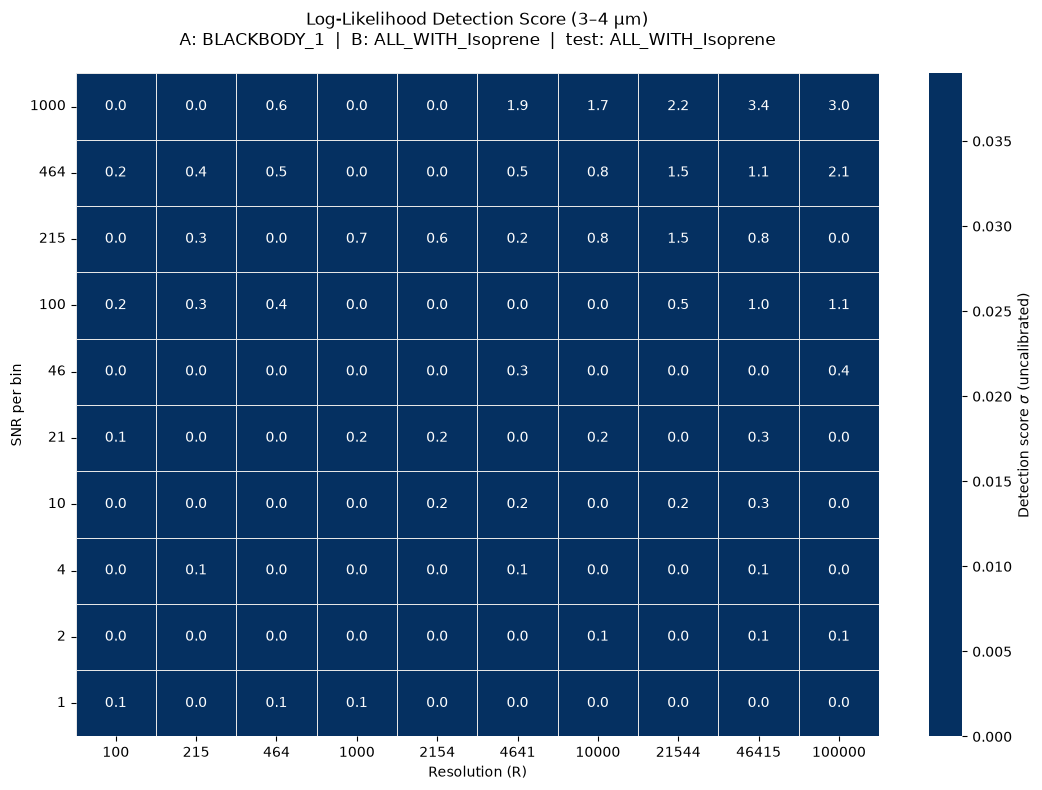

In [98]:


SIGMA_THRESH = 10.0

# ---------- pivot ----------
pivot = (
    df_cc_vsbb.pivot_table(
        index="snr",
        columns="resolution",
        values="sigma",
        aggfunc="mean",
    )
    .sort_index(ascending=False)  # high SNR at top
)

# numeric annotation
annot = pivot.map(lambda v: f"{v:.1f}" if np.isfinite(v) else "")

# color limits: robust to outliers (optional)
vmax = np.nanpercentile(pivot.values, 50)
vmin = 0.0  # detections only; use None + center=0 if signed null tests

fig, ax = plt.subplots(figsize=(11, 8))

hm = sns.heatmap(
    pivot,
    ax=ax,
    cmap="RdBu_r",
    center = 10,# sequential; use "RdBu_r" + center=0 if signed
    vmin=vmin,
    vmax=vmax,
    annot=annot,
    fmt="",
    linewidths=0.6,
    linecolor="0.9",
    cbar_kws={"label": r"Detection score $\sigma$ (uncalibrated)"},
    square=False,
)

# scientific tick labels
ax.set_xticklabels([f"{r:.0f}" for r in pivot.columns], rotation=0)
ax.set_yticklabels([f"{s:g}" for s in pivot.index], rotation=0)

# ---------- min SNR with σ ≥ 10 per resolution ----------
# heatmap coords: x = column index, y = row index
for j, R in enumerate(pivot.columns):
    col = pivot[R]
    ok = col[col >= SIGMA_THRESH]
    if ok.empty:
        continue
    # lowest SNR that still clears threshold
    snr_star = ok.index.min()
    i = list(pivot.index).index(snr_star)

    # rectangle around that cell (seaborn: cells are 1×1 starting at 0)
    rect = mpatches.Rectangle(
        (j, i), 1, 1,
        fill=False,
        edgecolor="red",
        linewidth=2.5,
        label=rf"min SNR for $\sigma\geq{SIGMA_THRESH:.0f}$" if j == 0 else None,
    )
    ax.add_patch(rect)

# legend only once
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, loc="upper left", frameon=True)

ax.set_xlabel("Resolution (R)")
ax.set_ylabel("SNR per bin")
ax.set_title(
    f"Log-Likelihood Detection Score ({wl_min_cc}–{wl_max_cc} µm)\n"
    f"A: {template_A}  |  B: {template_B}  |  test: {test_scen}\n"
    # f"Gold box = minimum SNR with σ ≥ {SIGMA_THRESH:.0f} (per R)"
)

plt.tight_layout()
plt.show()

# optional: print the threshold track
# print("Min SNR for σ ≥ 10 by resolution:")
# for R in pivot.columns:
#     col = pivot[R]
#     ok = col[col >= SIGMA_THRESH]
#     print(f"  R={R:.0e}: SNR≥{ok.index.min() if len(ok) else 'none'}")